In [1]:
import os
import multiprocessing as mp

# use all available cores
print('Using {} cores'.format(mp.cpu_count()))
xla_flag = '--xla_force_host_platform_device_count=' + str(mp.cpu_count())
os.environ['XLA_FLAGS']='--xla_force_host_platform_device_count=256'

import jax
import jax.numpy as jnp
from jax.random import normal, PRNGKey
from jax import lax
import numpy as np
import equinox as eqx
import diffrax as dfrx
import matplotlib.pyplot as plt 
import matplotlib as mpl
import sys
import time

# from joblib import Parallel, delayed

# add the odes directory to the path
sys.path.insert(0, '../odes')
import ampk_MM_double_mech_diffrax as model

# cpu mode
jax.config.update('jax_platform_name', 'cpu')
# tell Jax to use 64 bit precision
jax.config.update("jax_enable_x64", True)
%matplotlib inline
# plt.style.use('~/.matplotlib/custom.mplstyle')
# mpl.rcParams['figure.autolayout'] = True

Using 12 cores


In [2]:
len(jax.devices())

256

In [3]:
# metabolism_params
metab_parms_basal = {
    'kGly': 1300.0,
    'kHydro':1.4e-3,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5,
    'Kadp': 5.8e-2,
    'n': 2.568,}

metab_parms_stress = {
    'kGly': 4.5,
    'kHydro':1.4e-3,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5,
    'Kadp': 5.8e-2,
    'n': 2.568,}

# rhs 
rhs = model.ampk_MM_double_mech(**metab_parms_basal)
rhs_stress = model.ampk_MM_double_mech(**metab_parms_stress)
rhs = dfrx.ODETerm(rhs)
rhs_stress = dfrx.ODETerm(rhs_stress)
# model parameters
nominal_vals_MM = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   0.357, # kPhosCaMKK
   1.5e-2,  # KmCaMKK
   3.92e-2, # kPhosLKB1
   1.4,  # KmLKB1
   1.1e-1, # kDephosPP
   6.7e-2, # KmPP
   6.33, # kPhosAMPK
   4.67e-3, # KmAMPK
   1.1e-1, # kDephosPP1
   6.7e-2, # KmPP1
   1e-3, # AMPKAR
]

def compute_MM_params(params):
    return (
        1.0, # kOnAMP
        params[0], # kOffAMP
        1.0 , # kOnADP
        params[1], # kOffADP
        1.0, # kOnATP
        params[2], # kOffATP
        params[3], # kCaMKK
        params[4],  # KmCaMKK
        params[5], # kLKB1
        params[6],  # KmLKB1
        params[7], # kPP
        params[8], # KmPP
        params[9], # kAMPK
        params[10], # KmAMPK
        params[11], # kPP1
        params[12], # KmPP1
        1.0, # CaMKKtot
        1.0, # LKB1tot
        1.0, # PPtot
        1.0, # PP1tot
    )

# initial conditions
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR']

# initial conditions
to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'AMPKAR']
idxs = [state_names.index(item) for item in to_set]

print(idxs)

y0 = np.zeros((25,))
y0[idxs[0]] = 2e-5   # 'AMP' mM
y0[idxs[1]] = 1.3e-1 # 'ADP mM
y0[idxs[2]] = 8.2   # 'ATP mM
y0[idxs[3]] = 0.6   # 'AMPK mM
y0[idxs[4]] = 1.0   # 'AMPKAR mM

y0 = np.array(y0)

[0, 1, 2, 3, 23]


In [50]:
## Solver overhead
solver=dfrx.Kvaerno5()
stepsize_controller = dfrx.PIDController(rtol=1e-11, atol=1e-11)
t0 = 0.0
t1 = 1000000.0 # 1000 seconds
times = np.arange(t0, t1, 0.5)
dt0 = 1e-6 # initial time step
saveat=dfrx.SaveAt(ts=times)

# solve
sol_dfrx = dfrx.diffeqsolve(
    rhs, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=compute_MM_params(nominal_vals_MM))

print(sol_dfrx)

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[2000000],
  ys=f64[2000000,25],
  interpolation=None,
  stats={
    'max_steps':
    i64[],
    'num_accepted_steps':
    i64[],
    'num_rejected_steps':
    i64[],
    'num_steps':
    i64[]
  },
  result=i64[],
  solver_state=None,
  controller_state=None,
  made_jump=None
)


In [78]:
def deriv(t):
    "Uses quotient rule to compute derivative of pAMPKAR/AMPKAR"
    d_dt = rhs.vector_field(0.0, sol_dfrx.ys[t,:], compute_MM_params(nominal_vals_MM))
    ampkar = sol_dfrx.ys[t,23]
    pAmpkar = sol_dfrx.ys[t,24]

    return (ampkar*d_dt[24] - pAmpkar*d_dt[23])/(ampkar**2)
# /jnp.linalg.norm(rhs.vector_field(0.0, sol_dfrx.ys[0,:], compute_MA_params(nominal_vals_MA)))

tmax = 6000
ts_ds = [sol_dfrx.ts[i] for i in range(0,tmax, 200)]
derivs = [np.abs(deriv(t)) for t in range(0,tmax, 200)]

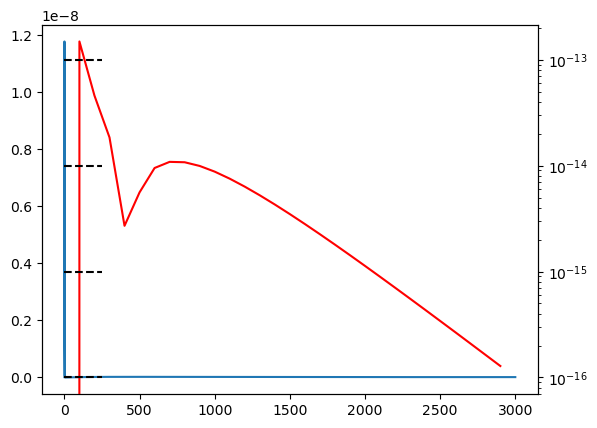

In [79]:
fig, ax = plt.subplots()
ax.plot(sol_dfrx.ts[0:tmax], sol_dfrx.ys[0:tmax,24]/sol_dfrx.ys[0:tmax,23]) #, label=state_names[i])
# ax.set_yscale('log')
ax2 = ax.twinx()
ax2.plot(ts_ds, derivs, color='red')
ax2.set_yscale('log')
ax2.plot([0, 250], [1e-16, 1e-16], color='black', linestyle='--')
ax2.plot([0, 250], [1e-15, 1e-15], color='black', linestyle='--')
ax2.plot([0, 250], [1e-14, 1e-14], color='black', linestyle='--')
ax2.plot([0, 250], [1e-13, 1e-13], color='black', linestyle='--')

In [80]:
@ jax.jit
def deriv(sol,  params, ampkar_idx=23, pampkar_idx=24):
    "Uses quotient rule to compute derivative of pAMPKAR/AMPKAR"
    d_dt = rhs.vector_field(0.0, sol.ys[-1,:], compute_MM_params(params))
    ampkar = sol.ys[-1,ampkar_idx]
    pAmpkar = sol.ys[-1,pampkar_idx]

    return (ampkar*d_dt[pampkar_idx] - pAmpkar*d_dt[ampkar_idx])/(ampkar**2)

## Now test a solve to steady-state function
# jitable function to run the system to steady-state
@jax.jit
def solve_to_steady_state(params, rhs, y0, thresh=1e-10):
    solver=dfrx.Kvaerno5()
    stepsize_controller = dfrx.PIDController(rtol=1e-10, atol=1e-10)
    t0 = 0.0
    t1 = 3000.0 # 1000 seconds
    times = jnp.arange(t0, t1, t1/100)
    dt0 = 1e-6 # initial time step
    saveat=dfrx.SaveAt(ts=times)
    repeat_step = 1000.0
    times_repeat = jnp.arange(t0, repeat_step, repeat_step/100)
    saveat_repeat=dfrx.SaveAt(ts=times_repeat)

    # initial solve
    sol = dfrx.diffeqsolve(
        rhs, 
        solver, 
        t0, t1, dt0, 
        y0, 
        saveat=saveat, stepsize_controller=stepsize_controller,
        args=params)

    # solve to steady-state
    # cond_fun checks for steady-state by checking the norm of the RHS
    # cond_fun = lambda sol: jnp.linalg.norm(rhs.vector_field(0.0, sol[0].ys[-1,:], params)) > thresh
    cond_fun = lambda sol: jnp.abs(deriv(sol[0], params)) > thresh
    # body_fun solves the ODEs for 100 more seconds
    body_fun = lambda sol: (dfrx.diffeqsolve(rhs, solver, t0, repeat_step, dt0, sol[0].ys[-1,:], 
        saveat=saveat_repeat, stepsize_controller=stepsize_controller, args=params),
        sol[1]+repeat_step)
    
    # while loop until steady state condition is reached
    sol_final = lax.while_loop(cond_fun, body_fun, (sol, t1))
    
    return sol_final # returns the final state

In [8]:
# run to steady-state
sol_ss = solve_to_steady_state(compute_M_params(nominal_vals_MA), rhs, y0, 1e-16)
t0 = 0.0
# new simulation for the time it too to reach steady-state
t1 = sol_ss[1] # 1000 seconds
print(t1)
times = np.arange(t0, t1, 0.5)
dt0 = 1e-6 # initial time step
saveat=dfrx.SaveAt(ts=times)

# solve
sol_dfrx = dfrx.diffeqsolve(
    rhs, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=compute_MA_params(nominal_vals_MA))

# apply stimulus and run again
sol_stim = solve_to_steady_state(compute_MA_params(nominal_vals_MA), rhs_stress, sol_ss[0].ys[-1,:], 1e-16)

t1 =  sol_stim[1] # 1000 seconds
times = np.arange(t0, t1, 1)
dt0 = 1e-3 # initial time step
saveat=dfrx.SaveAt(ts=times)

sol_stim = dfrx.diffeqsolve(
    rhs_stress, 
    solver, 
    t0, t1, dt0, 
    sol_ss[0].ys[-1,:],
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=compute_MA_params(nominal_vals_MA))

129000.0


Text(0.5, 1.0, 'Steady-state stimulus test (nominal parameters)')

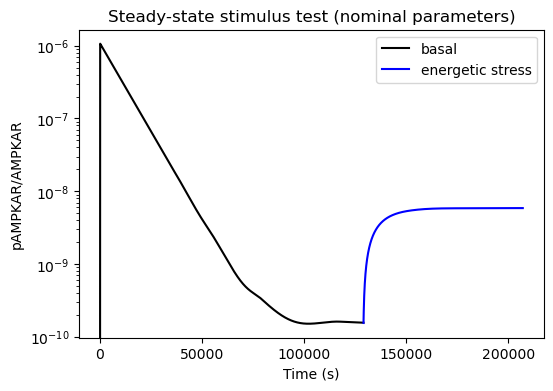

In [9]:
# make a plot
fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(sol_dfrx.ts, sol_dfrx.ys[:,23]/sol_dfrx.ys[:,22], 'k', label='basal')
ax.plot(sol_dfrx.ts[-1]+sol_stim.ts, sol_stim.ys[:,23]/sol_stim.ys[:,22], 'b', label='energetic stress')
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
ax.legend()
ax.set_title('Steady-state stimulus test (nominal parameters)')

In [13]:
@jax.jit
def single_model_eval(params, rhs_basal, rhs_stress, y0, ampkar_idx=22, pampkar_idx=23):
    # update y0 for AMPKAR
    y0 = y0.at[ampkar_idx].set(params[-1])

    # find basal steady-state
    sol_basal = solve_to_steady_state(params, rhs_basal, y0, 1e-16)

    # apply stimulus and run again
    sol_stress = solve_to_steady_state(params, rhs_stress, sol_basal[0].ys[-1,:], 1e-16)

    # compute the ratio of pAMPKAR/AMPKAR at the end of the stress simulation
    basal_ratio = sol_basal[0].ys[-1,pampkar_idx]/sol_basal[0].ys[-1,ampkar_idx]
    stress_ratio = sol_stress[0].ys[-1,pampkar_idx]/sol_stress[0].ys[-1,ampkar_idx]
    norm_change = (stress_ratio - basal_ratio) / basal_ratio
    
    return jnp.array([norm_change, basal_ratio, stress_ratio])

@jax.jit
def single_model_eval_nansafe(params, rhs_basal, rhs_stress, y0):
    pred = jnp.sum(jnp.isnan(params))
    false_fun = lambda params: single_model_eval(params, rhs_basal, rhs_stress, y0)
    true_fun = lambda params: jnp.array([jnp.nan, jnp.nan, jnp.nan])
    return lax.cond(pred, true_fun, false_fun, params)

In [14]:
qoi = single_model_eval(compute_MA_params(nominal_vals_MA), rhs, rhs_stress, y0)

In [15]:
qoi = single_model_eval_nansafe(np.array(compute_MA_params(nominal_vals_MA)), rhs, rhs_stress, y0)
print(qoi)

[3.67104309e+01 1.55833142e-10 5.87653492e-09]


In [16]:
%timeit single_model_eval(compute_MA_params(nominal_vals_MA), rhs, rhs_stress, y0)

33.1 ms ± 1.47 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
#with Parallel(n_jobs=8) as parallel:
#    p_list = [compute_MA_params(nominal_vals_MA) for i in range(16)]
#    sol_list = parallel(delayed(single_model_eval)(p, rhs, rhs_stress, y0) for p in p_list)

In [ ]:
# qoi_fn = lambda params: single_model_eval(params, rhs, rhs_stress, y0)
qoi_fn_pmap = jax.pmap(single_model_eval_nansafe, in_axes=(0, None, None, None))

In [ ]:
tmp = qoi_fn_pmap(jnp.array([compute_MA_params(nominal_vals_MA) for i in range(2)]), rhs, rhs_stress, y0)

In [ ]:
params = jnp.array([compute_MA_params(nominal_vals_MA) for i in range(256)])
key = jax.random.PRNGKey(1024)
params = params + 1e-5*normal(key, shape=params.shape)

tnow = time.time()
sols = []
for i in range(1):
    sol = qoi_fn_pmap(params, rhs, rhs_stress, y0)
    sols.append(sol)
tend = time.time()
print('It took {} seconds to run 1024 simulations'.format(tend-tnow))

It took 32.55074858665466 seconds to run 1024 simulations


In [ ]:
params = jnp.array([compute_MA_params(nominal_vals_MA) for i in range(1024)])
key = jax.random.PRNGKey(1024)
params = params + 1e-5*normal(key, shape=params.shape)


tnow = time.time()
sol = qoi_fn_pmap(params, rhs, rhs_stress, y0)
tend = time.time()
print('It took {} seconds to run 1024 simulations'.format(tend-tnow))

In [ ]:
qoi

Array([1.47137553e+02, 3.20965762e-14, 4.75470825e-12], dtype=float64)

In [ ]:
a = jnp.array([1.0, 2.0, 3.0])

func = lambda x: x+x
fn_pmap = jax.pmap(func, in_axes=(0,))

s = []
key = jax.random.PRNGKey(1024)
inputs = normal(key, shape=(2, 3, 3))
for i in range(inputs.shape[0]):
    sol = fn_pmap(inputs[i,:,:])
    s.append(sol)
print(np.array(s))
p = [func(x) for x in jnp.reshape(inputs, (6,3))]
print(p)

[[[ 2.83622311 -0.62610406  1.30584574]
  [ 0.05389066  3.32245488 -1.08353673]
  [ 1.04100329  1.51483855  0.99182168]]

 [[ 2.17866028  4.18578708 -0.08692813]
  [-0.96852003 -0.01025833  2.31745233]
  [-3.22320561 -3.41035414  0.77163512]]]
[Array([ 2.83622311, -0.62610406,  1.30584574], dtype=float64), Array([ 0.05389066,  3.32245488, -1.08353673], dtype=float64), Array([1.04100329, 1.51483855, 0.99182168], dtype=float64), Array([ 2.17866028,  4.18578708, -0.08692813], dtype=float64), Array([-0.96852003, -0.01025833,  2.31745233], dtype=float64), Array([-3.22320561, -3.41035414,  0.77163512], dtype=float64)]


In [ ]:
[func(x) for x in np.reshape(np.array(inputs), (6,3))]

[array([ 2.83622311, -0.62610406,  1.30584574]),
 array([ 0.05389066,  3.32245488, -1.08353673]),
 array([1.04100329, 1.51483855, 0.99182168]),
 array([ 2.17866028,  4.18578708, -0.08692813]),
 array([-0.96852003, -0.01025833,  2.31745233]),
 array([-3.22320561, -3.41035414,  0.77163512])]